In [ ]:
import numpy as np
from collections import Counter
from scipy.signal import resample, butter, filtfilt
from scipy.signal import square
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import os

ModuleNotFoundError: No module named 'matplotlib.pylot'

## Ejercicio 1

b)

In [2]:
def calcular_entropia(probabilidades):
    entropia = 0.0
    for proba in probabilidades:
        if proba > 0:
            entropia -= proba * np.log2(proba)
    return entropia # en bits/símbolo

c)

In [3]:
# P(S1) = 0.50, P(S2) = 0.25, P(S3) = P(S4) = 0.125
probabilidades_ej1 = [0.50, 0.25, 0.125, 0.125]

entropia = calcular_entropia(probabilidades_ej1)

print(f"Distribución de probabilidad: {probabilidades_ej1}")
print(f"La entropía H(S): {entropia} [bits/símbolo]")

Distribución de probabilidad: [0.5, 0.25, 0.125, 0.125]
La entropía H(S): 1.75 [bits/símbolo]


## Ejercicio 2

In [4]:
# codigo del ejercicio:
frecuencias_espanol = {
    'espacio': 0.145, 'e': 0.115, 'a': 0.105, 'o': 0.075, 's': 0.073,
    'n': 0.046, 'r': 0.045, 'i': 0.044, 'l': 0.040, 'd': 0.038,
    't': 0.035, 'u': 0.034, 'c': 0.030, 'm': 0.025, 'p': 0.020
}

prob_restante = 1.0 - sum(frecuencias_espanol.values())
prob_por_letra_rara = prob_restante / 13.0
print(f"Probabilidad restante para las 13 letras raras: {prob_restante:.6f}")
print(f"Probabilidad por letra rara: {prob_por_letra_rara:.6f}")
probabilidades_ej2 = list(frecuencias_espanol.values()) + [prob_por_letra_rara] * 13

Probabilidad restante para las 13 letras raras: 0.130000
Probabilidad por letra rara: 0.010000


a. calculamos la entropía H.

In [5]:
H = calcular_entropia(probabilidades_ej2)

print(f"entropía: {H} [bits/símbolo]")

entropía: 4.225630157929781 [bits/símbolo]


b. calculamos la H_max posible. esto sería para un alfabeto de 28 símbolos equiprobables (p = 1/28).

In [6]:
H_max = np.log2(28)

print(f"entropía máxima: {H_max} [bits/símbolo]")

entropía máxima: 4.807354922057604 [bits/símbolo]


c. calculamos el porcentaje de Redundancia del idioma español:

In [7]:
redundancia = (1 - (H / H_max)) * 100

print(f"redundancia: {redundancia:.2f}%")

redundancia: 12.10%


Hay simbolos que aparecen bastante mas, por lo que la prediccion esta "sesgada" hacia esas letras, lo que introduce redundancia.

## Ejercicio 3

a)

In [8]:
mensaje = "el veloz murcielago hindu comia feliz cardillo y kiwi"

tamano_msj = len(mensaje)
print(f"Cantidad total de caracteres: {tamano_msj}")

Cantidad total de caracteres: 53


b) frecuencia absoluta de cada carácter

In [9]:
frecuencias_absolutas = Counter(mensaje)

print("Frecuencia de cada carácter:")
for caracter, frecuencia in frecuencias_absolutas.items():
    print(f"'{caracter}': {frecuencia}")    

Frecuencia de cada carácter:
'e': 4
'l': 6
' ': 8
'v': 1
'o': 4
'z': 2
'm': 2
'u': 2
'r': 2
'c': 3
'i': 7
'a': 3
'g': 1
'h': 1
'n': 1
'd': 2
'f': 1
'y': 1
'k': 1
'w': 1


c) dividimos la frecuencia por la cantidad total de caracteres

In [10]:
probabilidades_ej3 = {}
for char, freq in frecuencias_absolutas.items():
    probabilidades_ej3[char] = freq / tamano_msj

print("Probabilidad de aparición de cada carácter:")
for caracter, probabilidad in probabilidades_ej3.items():
    print(f"'{caracter}': {probabilidad:.6f}")

Probabilidad de aparición de cada carácter:
'e': 0.075472
'l': 0.113208
' ': 0.150943
'v': 0.018868
'o': 0.075472
'z': 0.037736
'm': 0.037736
'u': 0.037736
'r': 0.037736
'c': 0.056604
'i': 0.132075
'a': 0.056604
'g': 0.018868
'h': 0.018868
'n': 0.018868
'd': 0.037736
'f': 0.018868
'y': 0.018868
'k': 0.018868
'w': 0.018868


d) calculamos la entropia del mensaje

In [11]:
lista_probabilidades = list(probabilidades_ej3.values())
entropia_mensaje = calcular_entropia(lista_probabilidades)

print(f"entropía: {entropia_mensaje} [bits/símbolo]")

entropía: 3.94167452129797 [bits/símbolo]


## Ejercicio 4


In [12]:
f_min = 10000  
f_max = 14000
P_tx = 5.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 4000 Hz
b. Potencia de la Señal Recibida (S): 0.0050 Watts
c. Potencia del Ruido Total (N): 0.0050 Watts
d. Capacidad del Canal (C): 4000 bps (4.0 kbps)
Capacidad del canal: 4.0 kbps | Tasa requerida: 12.0 kbps
NO es posible.


- podemos aumentar la potencia de transmisión Ptx : 

In [13]:
f_min = 10000  
f_max = 14000
P_tx = 35.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 4000 Hz
b. Potencia de la Señal Recibida (S): 0.0350 Watts
c. Potencia del Ruido Total (N): 0.0050 Watts
d. Capacidad del Canal (C): 12000 bps (12.0 kbps)
Capacidad del canal: 12.0 kbps | Tasa requerida: 12.0 kbps
SÍ es posible.


- modificar el transductor acustico para operar a 10Hz / 20hz

In [14]:
f_min = 15000
f_max = 45000
P_tx = 5.0  # potencia de transmisión en Watts de inicio
atenuacion_dB = 30 # atenuación total en dB
N0 = 1.25e-6 # densidad Espectral de Potencia del ruido en Watts/Hz
R_requerida = 12000 # Tasa de datos requerida para el video en bps (12 kbps)

# a) B = ancho de banda
B = f_max - f_min

# b) S = potencia de la Señal Recibida
# de: Atenuacion_dB = 10 * log10(P_tx / S), llegamos a la nueva formula:
S = P_tx / (10 ** (atenuacion_dB / 10))

# c) N = calcular Potencia del Ruido Total
N = N0 * B

# d) C = capacidad del canal
C = B * np.log2(1 + S / N)

print(f"a. Ancho de Banda físico (B): {B} Hz")
print(f"b. Potencia de la Señal Recibida (S): {S:.4f} Watts")
print(f"c. Potencia del Ruido Total (N): {N:.4f} Watts")
print(f"d. Capacidad del Canal (C): {C:.0f} bps ({C/1000:.1f} kbps)")

# factibilidad
print(f"Capacidad del canal: {C/1000:.1f} kbps | Tasa requerida: {R_requerida/1000:.1f} kbps")
if R_requerida <= C:
    print("SÍ es posible.")
else:
    print("NO es posible.")

a. Ancho de Banda físico (B): 30000 Hz
b. Potencia de la Señal Recibida (S): 0.0050 Watts
c. Potencia del Ruido Total (N): 0.0375 Watts
d. Capacidad del Canal (C): 5417 bps (5.4 kbps)
Capacidad del canal: 5.4 kbps | Tasa requerida: 12.0 kbps
NO es posible.


## Ejercicio 5

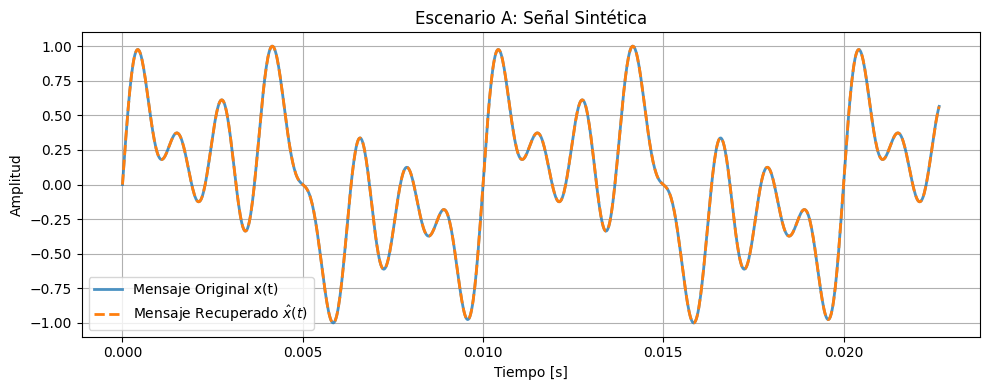

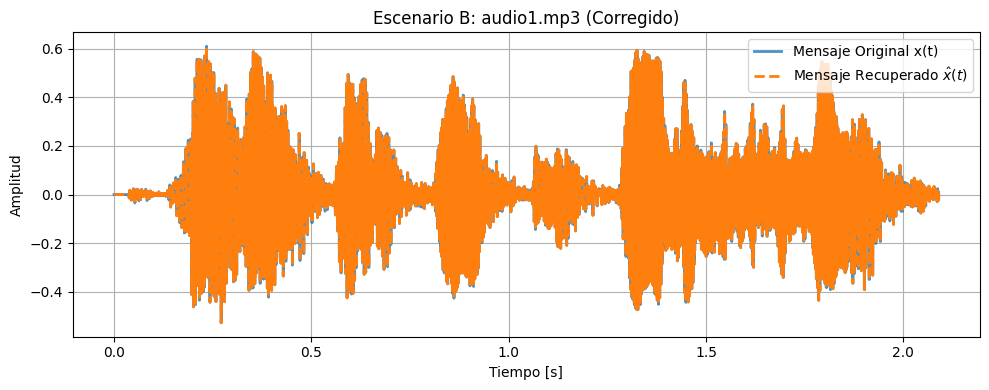

Archivo exportado sin distorsión: audio1_recuperado.wav


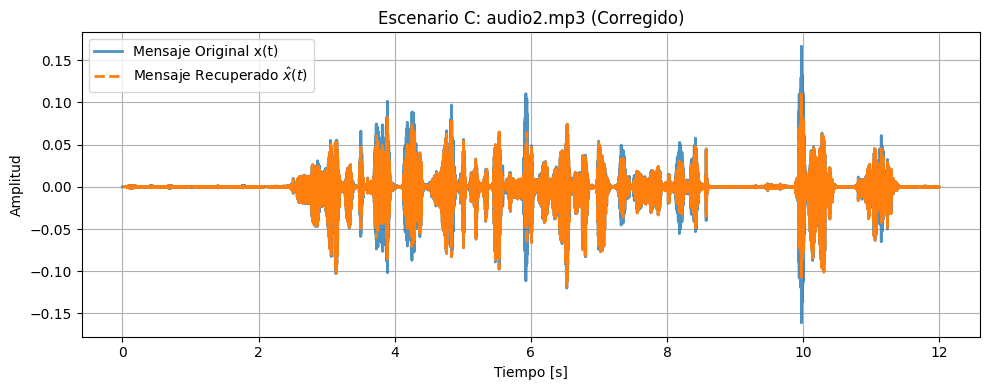

Archivo exportado sin distorsión: audio2_recuperado.wav


In [ ]:
# ==========================================
# a. Función de AM Síncrona (DSB-SC)
# ==========================================
def am_sincrona(x, fs, fc):
    t = np.arange(len(x)) / fs
    # 1) Transmisor
    portadora = np.cos(2 * np.pi * fc * t)
    s_t = x * portadora
    # 2) Receptor
    r_t = s_t * portadora
    # 3) Filtro Pasa Bajos de fase cero
    nyq = 0.5 * fs
    f_corte = fc * 0.8 
    normal_cutoff = f_corte / nyq
    
    b, a = butter(5, normal_cutoff, btype='low', analog=False)
    x_hat = filtfilt(b, a, r_t)
    
    # Compensación de ganancia teórica
    x_hat = x_hat * 2.0
    
    return s_t, x_hat

def plot_senales(t, x_original, x_recuperada, titulo, muestras=500):
    plt.figure(figsize=(10, 4))
    plt.plot(t[:muestras], x_original[:muestras], label='Mensaje Original x(t)', alpha=0.8, linewidth=2)
    plt.plot(t[:muestras], x_recuperada[:muestras], label=r'Mensaje Recuperado $\hat{x}(t)$', linestyle='--', linewidth=2)
    plt.title(titulo)
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # --- A: Señal Sintética ---
    fs_A = 44100 
    t_A = np.arange(0, 1.0, 1/fs_A) 
    
    x_A = (np.sin(2 * np.pi * 100 * t_A) + 
           np.sin(2 * np.pi * 300 * t_A) + 
           np.sin(2 * np.pi * 500 * t_A) + 
           np.sin(2 * np.pi * 800 * t_A))
    x_A = x_A / np.max(np.abs(x_A)) 
    fc_A = 10000 
    
    s_A, x_hat_A = am_sincrona(x_A, fs_A, fc_A)
    plot_senales(t_A, x_A, x_hat_A, 'Escenario A: Señal Sintética', muestras=1000)

    # --- B y C: Archivos de Audio ---
    archivos = {'B': 'audio1.mp3', 'C': 'audio2.mp3'}
    
    # Frecuencia portadora corregida para evitar aliasing en fs = 44100 Hz
    fc_audio = 8000 
    
    for escenario, archivo in archivos.items():
        if os.path.exists(archivo):
            x_audio, fs_audio = librosa.load(archivo, sr=None, mono=True)
            # Procesamiento AM
            s_audio, x_hat_audio = am_sincrona(x_audio, fs_audio, fc_audio)
            
            # Graficación de ventana temporal controlada
            t_audio = np.arange(len(x_audio)) / fs_audio
            muestras_plot = int(fs_audio * 12)
            plot_senales(t_audio, x_audio, x_hat_audio, f'Escenario {escenario}: {archivo} (Corregido)', muestras=muestras_plot)
            
            # Exportación
            archivo_salida = f"{archivo.split('.')[0]}_recuperado.wav"
            sf.write(archivo_salida, x_hat_audio, fs_audio)
            print(f"Archivo exportado sin distorsión: {archivo_salida}")
        else:
            print(f"[{escenario}] Archivo '{archivo}' no localizado.")

## Ejercicio 6

<>:56: SyntaxWarning: invalid escape sequence '\h'
<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:98: SyntaxWarning: invalid escape sequence '\h'
<>:56: SyntaxWarning: invalid escape sequence '\h'
<>:77: SyntaxWarning: invalid escape sequence '\h'
<>:98: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14004\3902615559.py:56: SyntaxWarning: invalid escape sequence '\h'
  axs[1].plot(t[:muestras], x_hat_opt[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14004\3902615559.py:77: SyntaxWarning: invalid escape sequence '\h'
  axs[1].plot(t[:muestras], x_hat_crit[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_14004\3902615559.py:98: SyntaxWarning: invalid escape sequence '\h'
  axs[1].plot(t[:muestras], x_hat_crit[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')


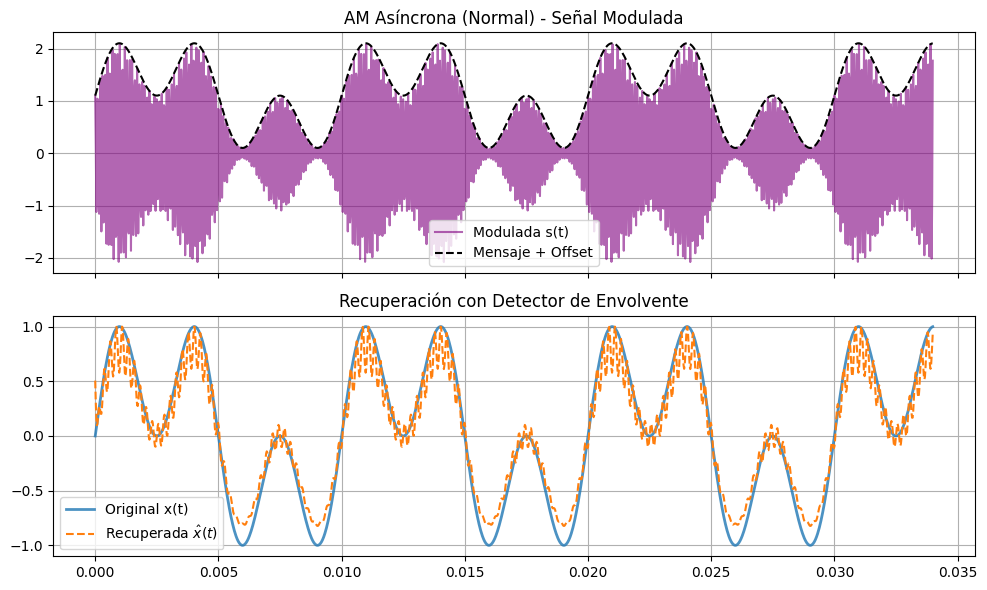

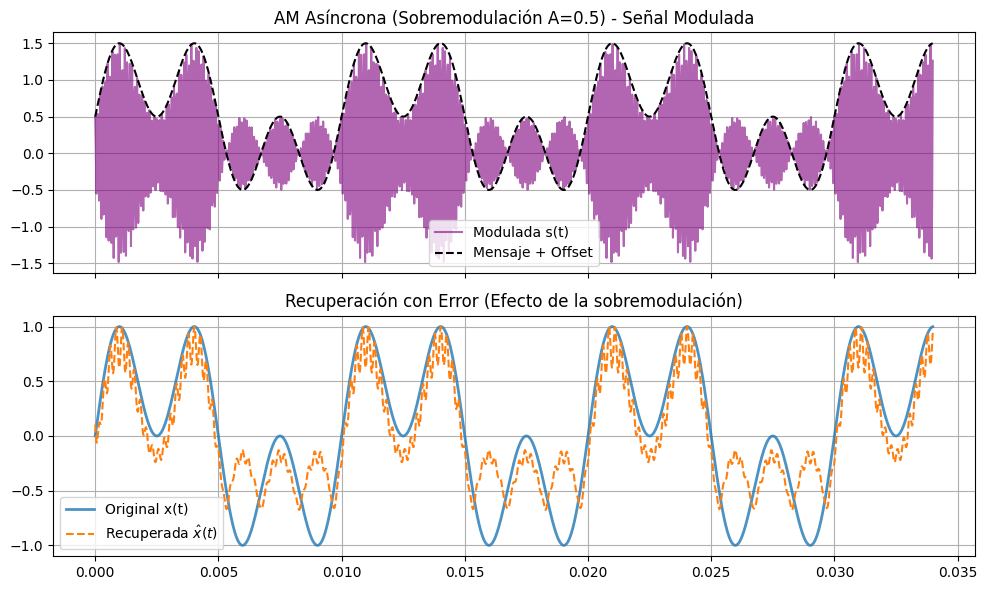

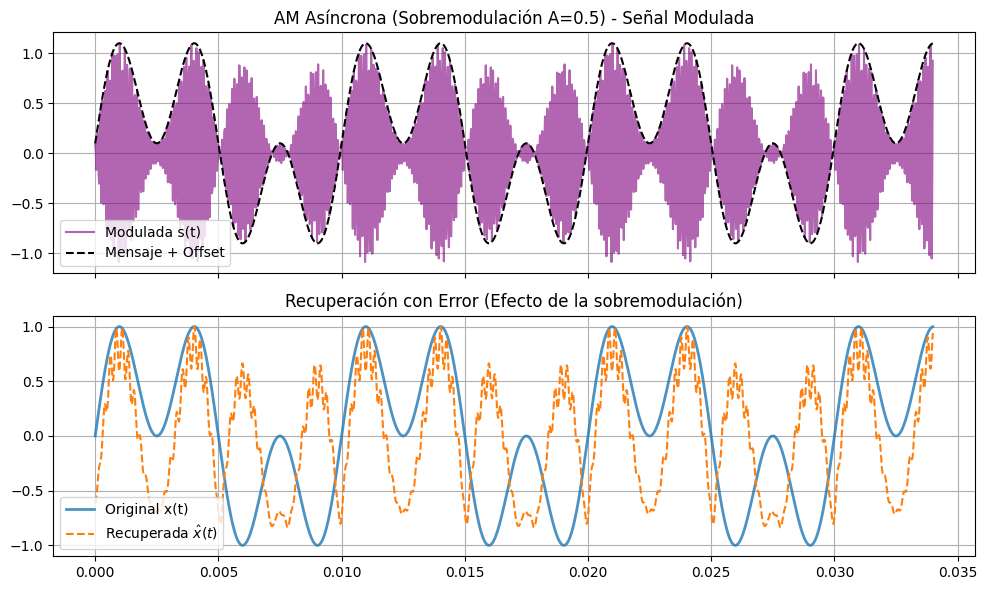

In [ ]:
def am_asincrona(x, fs, fc, A=None):
    t = np.arange(len(x)) / fs
    
    max_val = np.max(np.abs(x))
    
    # Si no nos pasan un offset 'A', calculamos uno óptimo (10% más grande que el pico máximo)
    if A is None:
        A = max_val * 1.1 
        
    portadora = np.cos(2 * np.pi * fc * t)
    s_t = (A + x) * portadora 
    
    # Simulación del Diodo (Rectificado)
    s_rect = np.abs(s_t)
    
    # Filtro Pasa Bajos
    nyq = 0.5 * fs
    f_corte = fc * 0.5
    b, a = butter(5, f_corte / nyq, btype='low')
    
    x_hat_raw = filtfilt(b, a, s_rect)
    
    # Bloqueo de DC y compensación de ganancia
    x_hat = x_hat_raw - np.mean(x_hat_raw)
    x_hat = x_hat * (np.max(np.abs(x)) / np.max(np.abs(x_hat)))
    
    return s_t, x_hat

# CONFIGURACIÓN INICIAL DE LA SEÑAL

fs = 44100
t = np.arange(0, 1.0, 1/fs)
x_synth = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 300 * t)
x_synth /= np.max(np.abs(x_synth)) # Normalizamos a [-1, 1]
fc_synth = 10000

# Parámetro visual para hacer zoom en los primeros ciclos
muestras = 1500 

# AM Normal (A óptimo automático)

s_opt, x_hat_opt = am_asincrona(x_synth, fs, fc_synth)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t[:muestras], s_opt[:muestras], color='purple', alpha=0.6, label='Modulada s(t)')
axs[0].plot(t[:muestras], x_synth[:muestras] + np.max(x_synth)*1.1, 'k--', label='Mensaje + Offset')
axs[0].set_title('AM Asíncrona (Normal) - Señal Modulada')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t[:muestras], x_synth[:muestras], label='Original x(t)', alpha=0.8, linewidth=2)
axs[1].plot(t[:muestras], x_hat_opt[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
axs[1].set_title('Recuperación con Detector de Envolvente')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Sobremodulación (Inciso C: A = 0.5 * max(|x|))

A_critico = 0.5 * np.max(np.abs(x_synth))
s_crit, x_hat_crit = am_asincrona(x_synth, fs, fc_synth, A=A_critico)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t[:muestras], s_crit[:muestras], color='purple', alpha=0.6, label='Modulada s(t)')
axs[0].plot(t[:muestras], x_synth[:muestras] + A_critico, 'k--', label='Mensaje + Offset')
axs[0].set_title('AM Asíncrona (Sobremodulación A=0.5) - Señal Modulada')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t[:muestras], x_synth[:muestras], label='Original x(t)', alpha=0.8, linewidth=2)
axs[1].plot(t[:muestras], x_hat_crit[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
axs[1].set_title('Recuperación con Error (Efecto de la sobremodulación)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Sobremodulación aspera (A = 0.1 * max(|x|))

A_critico = 0.1 * np.max(np.abs(x_synth))
s_crit, x_hat_crit = am_asincrona(x_synth, fs, fc_synth, A=A_critico)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t[:muestras], s_crit[:muestras], color='purple', alpha=0.6, label='Modulada s(t)')
axs[0].plot(t[:muestras], x_synth[:muestras] + A_critico, 'k--', label='Mensaje + Offset')
axs[0].set_title('AM Asíncrona (Sobremodulación A=0.5) - Señal Modulada')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t[:muestras], x_synth[:muestras], label='Original x(t)', alpha=0.8, linewidth=2)
axs[1].plot(t[:muestras], x_hat_crit[:muestras], label='Recuperada $\hat{x}(t)$', linestyle='--')
axs[1].set_title('Recuperación con Error (Efecto de la sobremodulación)')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
if __name__ == "__main__":
    # --- 1. CONFIGURACIÓN DE ENTORNO Y CARGA DE DATOS ---
    archivo_entrada = 'audio2.mp3'
    
    if os.path.exists(archivo_entrada):
        print(f"Cargando archivo real: {archivo_entrada}")
        x, fs = librosa.load(archivo_entrada, sr=None, mono=True)
        fc = 8000 # Portadora segura para evitar aliasing a fs=44100
    else:
        print("Archivo no detectado. Generando señal sintética de prueba...")
        fs = 44100
        t = np.arange(0, 1.0, 1/fs)
        x = np.sin(2 * np.pi * 100 * t) + np.sin(2 * np.pi * 300 * t)
        x /= np.max(np.abs(x))
        fc = 10000

    # --- 2. PROCESAMIENTO DE ESCENARIOS ---
    # Escenario A: Submodulada (Normal, sin distorsión)
    print("Procesando señal submodulada (normal)...")
    _, x_hat_normal = am_asincrona(x, fs, fc, A=None)

    # Escenario B: Sobremodulada (Con distorsión por cruce por cero)
    print("Procesando señal sobremodulada...")
    A_critico = 0.03 * np.max(np.abs(x))
    _, x_hat_sobremodulado = am_asincrona(x, fs, fc, A=A_critico)

    # --- 3. GESTIÓN DE CARPETAS Y EXPORTACIÓN ---
    nombre_carpeta = "audios_am_asincrona"
    
    # Crea la carpeta de forma segura si no existe previamente
    os.makedirs(nombre_carpeta, exist_ok=True)
    
    ruta_normal = os.path.join(nombre_carpeta, "audio_submodulado_normal.wav")
    ruta_sobre = os.path.join(nombre_carpeta, "audio_sobremodulado_distorsionado.wav")
    
    # Escritura física en disco
    sf.write(ruta_normal, x_hat_normal, fs)
    sf.write(ruta_sobre, x_hat_sobremodulado, fs)
    
    print("\n[PROCESO COMPLETADO EXI] ==================================")
    print(f"Se ha creado la carpeta: {os.path.abspath(nombre_carpeta)}")
    print(f"1. Archivo limpio guardado en: {ruta_normal}")
    print(f"2. Archivo distorsionado guardado en: {ruta_sobre}")
    print("==========================================================")

Cargando archivo real: audio2.mp3
Procesando señal submodulada (normal)...
Procesando señal sobremodulada...

[PROCESO COMPLETADO EXI] ==================================
Se ha creado la carpeta: d:\existencia\facu cosa\pds\pds\TP5\audios_am_asincrona
1. Archivo limpio guardado en: audios_am_asincrona\audio_submodulado_normal.wav
2. Archivo distorsionado guardado en: audios_am_asincrona\audio_sobremodulado_distorsionado.wav


## Ejercicio 7

In [ ]:
def modulacion_fm(x, fs, fc, kf):
    t = np.arange(len(x)) / fs
    dt = 1 / fs
    # La integral se aproxima con suma acumulativa por dt
    integral_x = np.cumsum(x) * dt
    # Ecuación de FM: y(t) = cos(2*pi*fc*t + 2*pi*kf * integral(x))
    y = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_x)
    return y

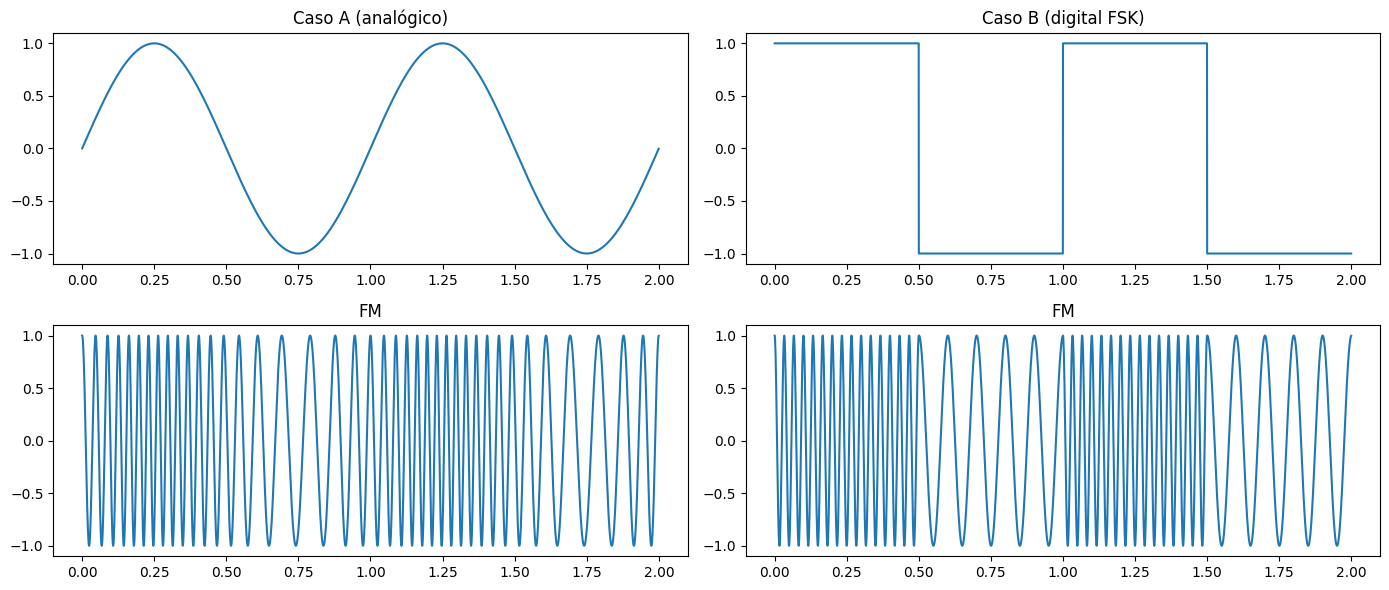

In [ ]:
fs = 2000
t = np.arange(0, 2, 1/fs) # 2 segundos de transmisión
fc = 20                   # Frecuencia portadora
kf = 10                   # Desviación

# señales moduladoras de 1 Hz
x_A = np.sin(2 * np.pi * 1 * t)
x_B = square(2 * np.pi * 1 * t)

# modulacion FM de ambas señales
y_A = modulacion_fm(x_A, fs, fc, kf)
y_B = modulacion_fm(x_B, fs, fc, kf)

plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1); plt.plot(t, x_A); plt.title("Caso A (analógico)")
plt.subplot(2, 2, 3); plt.plot(t, y_A); plt.title("FM")

plt.subplot(2, 2, 2); plt.plot(t, x_B); plt.title("Caso B (digital FSK)")
plt.subplot(2, 2, 4); plt.plot(t, y_B); plt.title("FM")

plt.tight_layout()
plt.show()

In [ ]:
pot_portadora = np.mean(np.cos(2 * np.pi * fc * t)**2)
pot_yA = np.mean(y_A**2)
pot_yB = np.mean(y_B**2)

print(f"Potencia Portadora sin modular: {pot_portadora:.3f}")
print(f"Potencia Señal FM (Caso A): {pot_yA:.3f}")
print(f"Potencia Señal FM (Caso B): {pot_yB:.3f}")

Potencia Portadora sin modular: 0.500
Potencia Señal FM (Caso A): 0.500
Potencia Señal FM (Caso B): 0.500


La potencia de una señal depende directamente de su amplitud (su voltaje máximo). En la modulación FM, la amplitud jamás cambia.
En AM, la antena tiene que gastar energía dependiendo del volumen del mensaje, lo cual es ineficiente y requiere amplificadores muy caros. 
En FM, al mantener una potencia constante, el equipo de transmisión es mucho más eficiente. Además, es inmune al ruido.

## Ejercicio 8

Multiplexado por división de frecuencia (FDM)

In [ ]:
ecg = np.loadtxt('ecg.txt')
fs_ecg = 250

pa = np.loadtxt('pa.txt')
fs_pa= 100

voz = np.loadtxt('voz.txt')
fs_voz = 8000

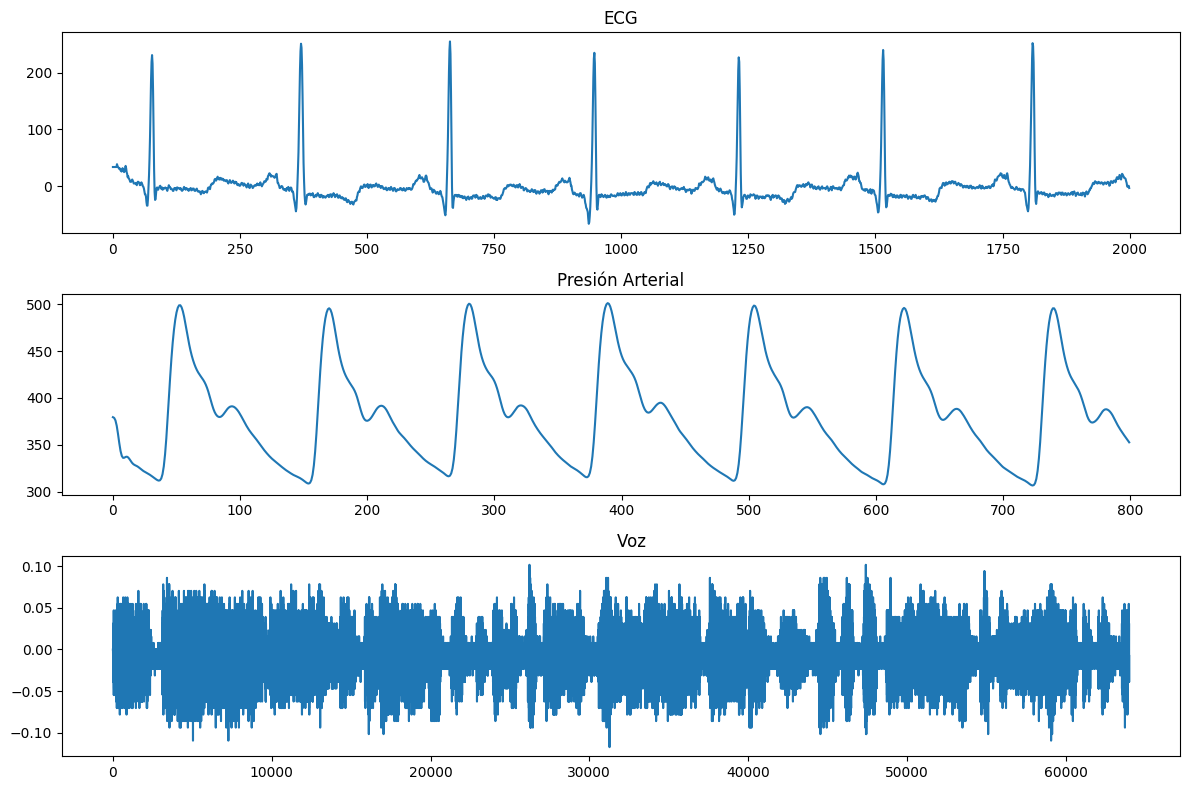

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1); plt.plot(ecg); plt.title("ECG")
plt.subplot(3, 1, 2); plt.plot(pa); plt.title("Presión Arterial")
plt.subplot(3, 1, 3); plt.plot(voz); plt.title("    Voz")
plt.tight_layout()

In [ ]:
# frecuencia de muestreo común a 120 kHz, debe ser más del doble de la portadora más alta (50 kHz) por el Teorema de Nyquist.
fs_comun = 120000 
duracion = len(voz) / fs_voz  # Asumimos que la voz marca el tiempo total ya que es la mas muestreada
N_comun = int(duracion * fs_comun)
t = np.linspace(0, duracion, N_comun, endpoint=False)

# Resampleamos todas al mismo "tamaño" (fs_comun)
ecg_r = resample(ecg, N_comun)
pa_r = resample(pa, N_comun)
voz_r = resample(voz, N_comun)

# Definimos las 3 portadoras (entre 30 y 50 kHz como pide el TP)
f1, f2, f3 = 30000, 40000, 50000 

# Modulación AM Síncrona
tx_ecg = ecg_r * np.cos(2 * np.pi * f1 * t)
tx_pa  = pa_r  * np.cos(2 * np.pi * f2 * t)
tx_voz = voz_r * np.cos(2 * np.pi * f3 * t)

# multiplexado
senal_aire = tx_ecg + tx_pa + tx_voz

In [ ]:
# función  para crear y aplicar filtros
def aplicar_filtro(senal, frec_corte, tipo):
    b, a = butter(4, frec_corte, btype=tipo, fs=fs_comun)
    return filtfilt(b, a, senal)

rx_ecg = aplicar_filtro(senal_aire, [29000, 31000], 'bandpass') # Separar carril
rx_ecg = rx_ecg * np.cos(2 * np.pi * f1 * t)                    # Demodular
rx_ecg = aplicar_filtro(rx_ecg, fs_ecg/2, 'low')                # Limpiar (Pasabajos a la freq original)

rx_pa = aplicar_filtro(senal_aire, [39000, 41000], 'bandpass')
rx_pa = rx_pa * np.cos(2 * np.pi * f2 * t)
rx_pa = aplicar_filtro(rx_pa, fs_pa/2, 'low')

rx_voz = aplicar_filtro(senal_aire, [45000, 55000], 'bandpass')
rx_voz = rx_voz * np.cos(2 * np.pi * f3 * t)
rx_voz = aplicar_filtro(rx_voz, fs_voz/2, 'low')

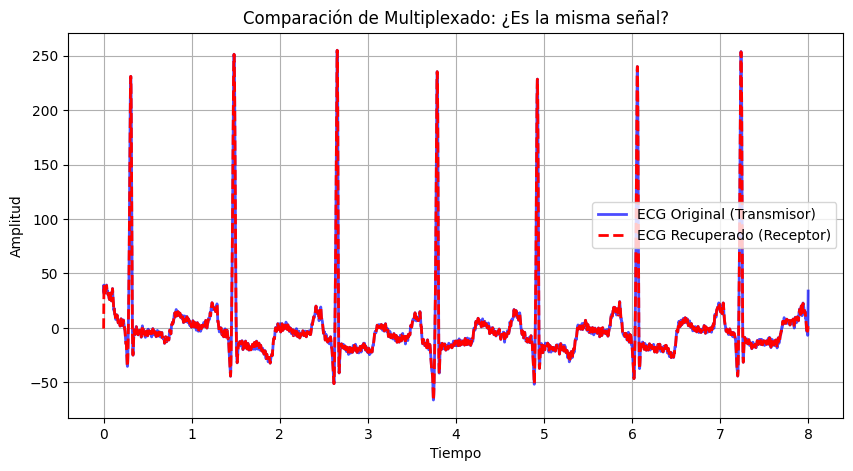

In [ ]:
# compensamos la pérdida de amplitud multiplicando por 2
rx_ecg_ajustado = rx_ecg * 2 

plt.figure(figsize=(10, 5))

muestras = 2000000 

plt.plot(t[:muestras], ecg_r[:muestras], label='ECG Original (Transmisor)', color='blue', linewidth=2, alpha=0.7)
plt.plot(t[:muestras], rx_ecg_ajustado[:muestras], label='ECG Recuperado (Receptor)', color='red', linestyle='dashed', linewidth=2)
plt.title("Comparación de Multiplexado: ¿Es la misma señal?")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

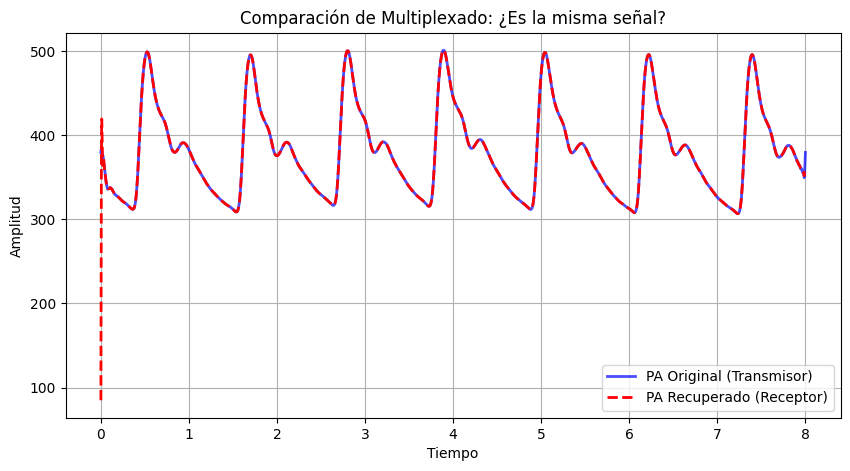

In [ ]:
# compensamos la pérdida de amplitud multiplicando por 2
rx_pa_ajustado = rx_pa * 2 

plt.figure(figsize=(10, 5))

muestras = 2000000 

plt.plot(t[:muestras], pa_r[:muestras], label='PA Original (Transmisor)', color='blue', linewidth=2, alpha=0.7)
plt.plot(t[:muestras], rx_pa_ajustado[:muestras], label='PA Recuperado (Receptor)', color='red', linestyle='dashed', linewidth=2)
plt.title("Comparación de Multiplexado: ¿Es la misma señal?")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()

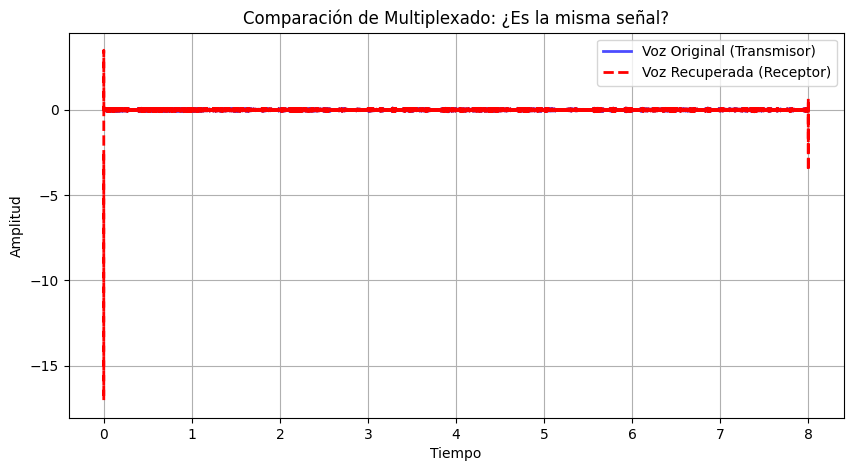

In [ ]:
# compensamos la pérdida de amplitud multiplicando por 2
rx_voz_ajustado = rx_voz * 2 

plt.figure(figsize=(10, 5))

muestras = 2000000 

plt.plot(t[:muestras], voz_r[:muestras], label='Voz Original (Transmisor)', color='blue', linewidth=2, alpha=0.7)
plt.plot(t[:muestras], rx_voz_ajustado[:muestras], label='Voz Recuperada (Receptor)', color='red', linestyle='dashed', linewidth=2)
plt.title("Comparación de Multiplexado: ¿Es la misma señal?")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.show()